# Shor's Algorithm — Beauregard Oracle

This notebook implements the **controlled modular multiplication circuit** ($C$-$U_a$) at the heart of Shor's algorithm, following [Beauregard (2003)](https://arxiv.org/abs/quant-ph/0205095) to use only $2n+3$ qubits for an $n$-bit modulus.

## Architecture overview

The circuit is built from four nested layers:

| Layer | Gate | What it does |
|---|---|---|
| 1 | $\varphi\text{ADD}(a)$ | Addition: adds a classical constant $a$ (frequency domain) |
| 2 | $\varphi\text{ADD}(a)\text{MOD}(N)$ | Modular addition: use an ancilla to detect/correct overflow (frequency domain)  |
| 3 | $\text{CMULT}(a)\text{MOD}(N)$ | Multiply: controlled mapping $x, b \mapsto x, (b + ax) \bmod N$ |
| 4 | $C\text{-}U_a$ | Full circuit: controlled mapping $x \mapsto ax \bmod N$ via multiply–swap–unmultiply |

The register layout is `c(1) | x(n) | b(n+1) | anc(1)` $\rightarrow$ $2n+3$ qubits total.


In [1]:
from collections import defaultdict
from fractions import Fraction
import math

from IPython.display import HTML
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import Qubit
from qiskit.synthesis.qft import synth_qft_full
from qiskit_aer import AerSimulator

# The Oracle Function

In [2]:
class ShorOracle:
    """
    A class implementing Beauregard's (2003) controlled modular multiplication using 2n+3 qubits.
    """
    def __init__(self, a: int, N: int):
        if not (0 < a < N):
            raise ValueError(f"Need 0 < a < N but got a={a}, N={N}.")
        if math.gcd(a, N) != 1:
            raise ValueError(f"a={a} and N={N} are not coprime!")

        self.a = a
        self.N = N
        self.n = math.ceil(math.log2(self.N))
        
        # Registers (2n+3)
        self.c = QuantumRegister(1, 'c')
        self.x = QuantumRegister(self.n, 'x')
        self.b = QuantumRegister(self.n+1, 'b') # 1 extra qubit to handle overflow
        self.anc = QuantumRegister(1, 'anc')

        # Subcircuits (accessible for drawing)
        self.cmult_fwd = self._multiplier(self.a)
        self.cmult_fwd.name = f"CMULT({self.a})mod{self.N}"

        a_inv = pow(self.a, -1, self.N)
        self.cmult_inv = self._multiplier(a_inv).inverse()
        self.cmult_inv.name = f"CMULT({a_inv})†mod{self.N}"

        self.example_mod_adder = self._mod_adder(self.a % self.N)
        self.example_adder = self._adder(self.a)

        self.qc = self._build()


    def _qft(self, qc: QuantumCircuit, qubits: list[Qubit], inverse: bool=False) -> None:
        gate = synth_qft_full(self.n + 1, do_swaps=False, inverse=inverse)
        inv_label = "†" if inverse else ""
        gate.name = "QFT" + inv_label
        qc.append(gate, qubits)


    def _adder(self, a: int, num_controls: int = 0, inverse: bool = False) -> QuantumCircuit:
        """Beauregard Fig.3: the adder gate, φADD(a). Control bits appear last."""
        target = QuantumRegister(self.n + 1, 'φ(b)')
        control_registers = [QuantumRegister(1, f'c{i}') for i in range(num_controls)]

        registers = [target] + control_registers
        inv_label = "†" if inverse else ""
        control_label = f"C{num_controls}-" if num_controls > 0 else ""
        qc = QuantumCircuit(*registers, name=f"{control_label}φADD({a}){inv_label}")

        sign = -1 if inverse else 1

        for j in range(self.n + 1):
            theta = sign * 2 * math.pi * a / (2 ** (j + 1))

            if not control_registers:
                qc.p(theta, target[j])
            elif num_controls == 1:
                qc.cp(theta, control_registers[0], target[j])
            elif num_controls == 2:
                qc.mcp(theta, control_registers, target[j])

        return qc


    def _mod_adder(self, a: int) -> QuantumCircuit:
        """Beauregard Fig.5: the modular adder gate, φADD(a)MOD(N)."""
        ctrl1 = QuantumRegister(1, 'c1')
        ctrl2 = QuantumRegister(1, 'c2')
        target = QuantumRegister(self.n + 1, 'φ(b)')
        ancilla = QuantumRegister(1, 'anc')

        qc = QuantumCircuit(ctrl1, ctrl2, target, ancilla, name=f"φADD({a})mod{self.N}")
        target = list(target)
        cc = [ctrl1[0], ctrl2[0]]

        # Compute phi(a + b - N)
        qc.append(self._adder(a, num_controls=2).to_instruction(), target + cc)
        qc.append(self._adder(self.N, inverse=True).to_instruction(), target)

        # Check if a + b - N < 0
        self._qft(qc, target, inverse=True)
        qc.cx(target[self.n], ancilla[0])
        self._qft(qc, target)

        # If so, then add back N
        qc.append(self._adder(self.N, num_controls=1).to_instruction(), target + [ancilla[0]])

        # Clear the ancilla bit
        qc.append(self._adder(a, num_controls=2, inverse=True).to_instruction(), target + cc)
        self._qft(qc, target, inverse=True)
        qc.x(target[self.n])
        qc.cx(target[self.n], ancilla[0])
        qc.x(target[self.n])
        self._qft(qc, target)
        qc.append(self._adder(a, num_controls=2).to_instruction(), target + cc)

        return qc


    def _multiplier(self, a: int) -> QuantumCircuit:
        """Beauregard Fig.6: the controlled multiplier gate, CMULT(a)MOD(N)."""
        qc = QuantumCircuit(
            self.c, 
            self.x, 
            self.b, 
            self.anc,
            name=f"CMULT({a})MOD{self.N}")
        
        self._qft(qc, self.b)

        for i in range(self.n):
            a_shifted = (a * pow(2, i, self.N)) % self.N

            qc.append(
                self._mod_adder(a_shifted).to_instruction(),
                [self.c[0], self.x[i]] + list(self.b) + [self.anc[0]])

        self._qft(qc, self.b, inverse=True)

        return qc


    def _build(self) -> QuantumCircuit:
        """Beauregard Fig.7: the full C-Ua oracle."""
        qc = QuantumCircuit(
            self.c, 
            self.x, 
            self.b, 
            self.anc, 
            name=f'C-U_{self.a}MOD({self.N})')
        
        qc.append(self.cmult_fwd.to_instruction(), qc.qubits)

        for i in range(self.n):
            qc.cswap(self.c[0], self.x[i], self.b[i])

        qc.append(self.cmult_inv.to_instruction(), qc.qubits)
        
        return qc


    def __repr__(self) -> str:
        return f"ShorOracle(a={self.a}, N={self.N}; n={self.n}, qubits={self.qc.num_qubits})"

### Modular adder (Beauregard, Fig. 5; see `_mod_adder` above)
---
The modular adder $\varphi\text{ADD}(a)\text{MOD}(N)$ is the most difficult piece, since it must compute $b \mapsto (b + a) \bmod N$ **reversibly**, using a single ancilla qubit to detect overflow without resorting to measuring.

The procedure is as follows, with the ancilla bit initialized to $|0\rangle$. Operations are in the frequency domain unless otherwise noted:

1. **Add $a$**: Doubly-controlled $\varphi\text{ADD}(a)$ maps $b$ to $b+a$.
2. **Subtract $N$**: Uncontrolled $\varphi\text{ADD}(N)^\dagger$ yields $b + a - N$.
   - However, if $a + b < N$, then we want to undo the subtraction of $N$, so next...
3. **Set the ancilla**: Apply $\operatorname{QFT}^\dagger$ to recover an integer. If $b + a - N < 0$, then the most significant bit (MSB) is $|1\rangle$; copy it into the ancilla via $\operatorname{CNOT}$ and then reapply $\operatorname{QFT}$.
   - The ancilla is now $|1\rangle$ if and only if $b + a < N$.
4. **Conditionally undo subtraction**: Ancilla-controlled $\varphi\text{ADD}(N)$ adds $N$ back if and only if the ancilla is $|1\rangle$.
   - This yields $(b + a) \bmod N$ as desired.
   - The ancilla, however, is still dirty.
5. **Uncompute the ancilla**: Apply $\varphi\text{ADD}(a)^\dagger$ and $\operatorname{QFT}^\dagger$ to get $(b + a) \bmod N - a$. By the identity $$(a + b)\bmod N \geq a \Leftrightarrow a + b < N,$$ the MSB here is $|0\rangle$ precisely when the ancilla is $|1\rangle$. Hence, a $\operatorname{NOT}-\operatorname{CNOT}-\operatorname{NOT}$ sequence on the MSB applied to the ancilla resets the latter, thus disentangling it from the register. A final $\operatorname{QFT}$ and $\varphi\text{ADD}(a)$ restore the register to $(b + a) \bmod N$ in the frequency domain.

## An Example $(N = 15)$

In [3]:
sim = AerSimulator(method='statevector')

def read_x(outcome: int, n: int) -> int:
    """Extract x register from statevector and convert from binary to decimal."""
    return sum(((outcome >> (1 + i)) & 1) << i for i in range(n))


def is_scratch_reset(outcome: int, n: int, num_qubits: int) -> bool:
    """Check b register, overflow, and ancilla are all |0⟩."""
    return not any((outcome >> i) & 1 for i in range(1 + n, num_qubits))


def test_oracle(a: int, N: int) -> bool:
    oracle = ShorOracle(a, N)

    def run(ctrl_val: int, x_val: int) -> tuple[int, bool]:
        qc = QuantumCircuit(oracle.qc.num_qubits)
        if ctrl_val: qc.x(0)
        for i in range(oracle.n):
            if (x_val >> i) & 1: qc.x(1 + i)

        qc.compose(oracle.qc, inplace=True)
        qc.save_statevector()  # type: ignore[attr-defined]
        sv = sim.run(transpile(qc, sim)).result().get_statevector()
        outcome = int(np.argmax(np.abs(sv.data)))
        
        is_clean = is_scratch_reset(outcome, oracle.n, oracle.qc.num_qubits)
        is_high_prob = abs(sv.data[outcome]) > 1 - 1e-10 # Check if the probability is practically 1

        return read_x(outcome, oracle.n), is_clean & is_high_prob

    errors = 0
    for x_val in range(N):
        for ctrl_val, expected in [(1, (a * x_val) % N), (0, x_val)]:
            x_out, clean = run(ctrl_val, x_val)
            if x_out != expected or not clean:
                print(f"  ctrl={ctrl_val} x={x_val}: got {x_out} exp {expected} clean={clean} ❌")
                errors += 1

    if errors == 0:
        print(f"a={a:2d}, N={N} | {oracle.qc.num_qubits} qubits (2n+3={2 * oracle.n + 3}) | All passed ☑️")
        return True
    else:
        print(f"a={a:2d}, N={N} | {oracle.qc.num_qubits} qubits (2n+3={2 * oracle.n + 3}) | {errors} ❌")
        return False

In [4]:
N = 15

# No need to check 1, since its order is always 1
results = [test_oracle(a, N) for a in range(2, N) if math.gcd(a, N) == 1]

assert all(results), "Some tests failed!"

a= 2, N=15 | 11 qubits (2n+3=11) | All passed ☑️
a= 4, N=15 | 11 qubits (2n+3=11) | All passed ☑️
a= 7, N=15 | 11 qubits (2n+3=11) | All passed ☑️
a= 8, N=15 | 11 qubits (2n+3=11) | All passed ☑️
a=11, N=15 | 11 qubits (2n+3=11) | All passed ☑️
a=13, N=15 | 11 qubits (2n+3=11) | All passed ☑️
a=14, N=15 | 11 qubits (2n+3=11) | All passed ☑️


In [5]:
# Example Circuit Summary for (a=7, N=15)
a = 7
N = 15

oracle = ShorOracle(a, N)
compiled = transpile(oracle.qc, AerSimulator())
ops = compiled.count_ops()

html = f"""
<table style="border-collapse: collapse; font-family: monospace;">
  <tr><th colspan="2" style="text-align:left; padding: 8px; border-bottom: 2px solid #333;">
    Circuit Summary: a={oracle.a}, N={oracle.N}
  </th></tr>
  <tr><td style="padding: 4px 12px;">Qubits</td>
      <td style="padding: 4px 12px;">{compiled.num_qubits}</td></tr>
  <tr><td style="padding: 4px 12px;">Depth</td>
      <td style="padding: 4px 12px;">{compiled.depth()}</td></tr>
  <tr><td style="padding: 4px 12px;">Total gates</td>
      <td style="padding: 4px 12px;">{sum(ops.values())}</td></tr>
  <tr><td colspan="2" style="padding: 8px 12px 4px; border-top: 1px solid #ccc;">
    <b>Gate breakdown</b>
  </td></tr>
  {"".join(f'<tr><td style="padding: 2px 12px; color: #666;">{gate}</td><td style="padding: 2px 12px;">{count}</td></tr>' 
           for gate, count in sorted(ops.items(), key=lambda x: -x[1]))}
</table>
"""
display(HTML(html))

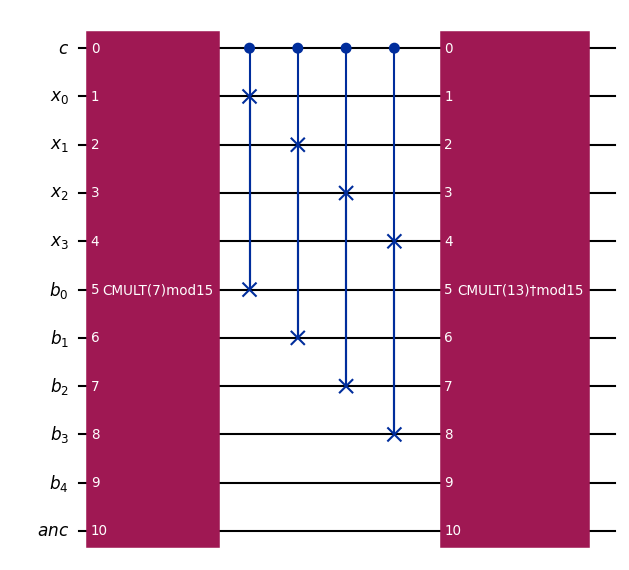

In [6]:
oracle.qc.draw("mpl", scale=0.75)

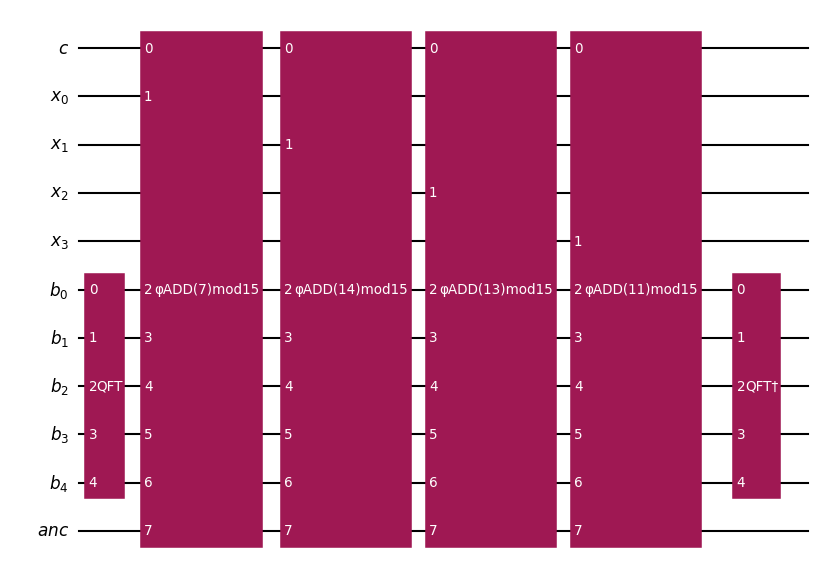

In [7]:
oracle.cmult_fwd.draw("mpl", scale=0.75)

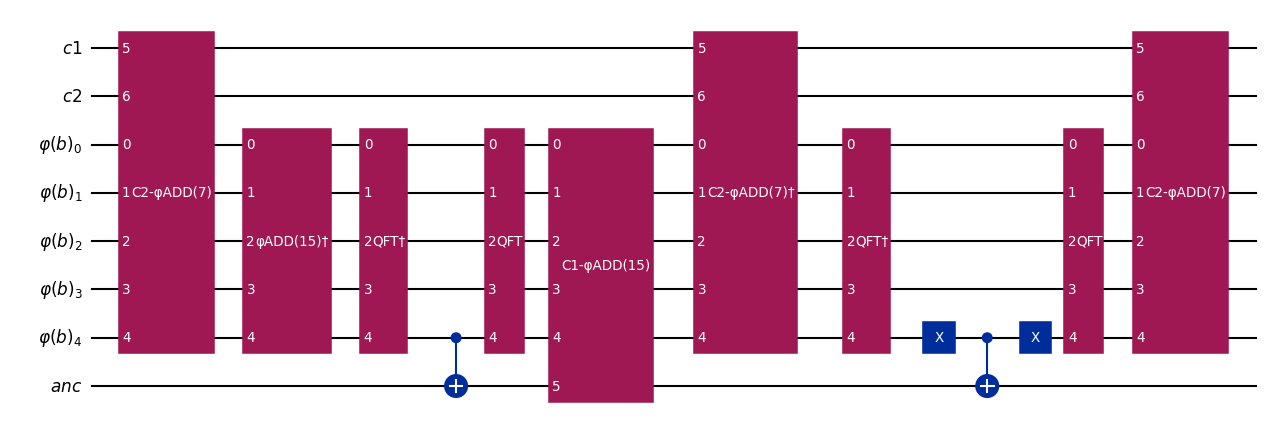

In [8]:
oracle.example_mod_adder.draw("mpl", scale=0.75)

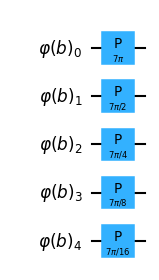

In [9]:
oracle.example_adder.draw("mpl", scale=0.75)

# Demo: Shor's Algorithm (Full)

## Full Shor's Algorithm: Quantum Phase Estimation

With the oracle verified, we now build the complete QPE circuit to factor $N = 15$. For the sake of demonstration, we choose $a=7$ in advance.

**Why QPE finds the order:** The oracle $U_a$ has eigenstates whose phases are multiples of $1/r$, where $r$ is the multiplicative order of $a$ mod $N$ (i.e. the smallest $r$ with $a^r \equiv 1$). QPE extracts these phases into the counting register.

**Circuit structure** ($4n + 3$ qubits total):
 - Counting ($2n$ qubits): $|+\rangle^{\otimes 2n} --- \operatorname{QFT}\dagger --- \text{measure}$
 - Oracle (2n+3 qubits): The $x$ register is initialized to $|1\rangle$ so that repeated application of $U_a$ cycles through $a^k \bmod N$
 - The $x$ register is initialized to $|1\rangle$ so that repeated application of $U_a$ cycles through $a^k \bmod N$
 - Each counting qubit $j$ controls $U_{a^{2^j}}$, which we implement by building a fresh `ShorOracle` for the pre-computed classical value $a^{2^j} \bmod N$.
 - After the inverse QFT, measurement outcomes cluster at integer multiples of $2^{2n}/r$

## Classical post-processing: continued fractions

The measurement gives an integer $c$ from the counting register. The **phase** is $\phi = c / 2^{2n}$, which is close to some multiple $k/r$ of $1/r$.

We recover $r$ using the **continued fraction algorithm**: `Fraction(ϕ).limit_denominator(N)` finds the closest rational to $\phi$ with denominator $\leq N$. This denominator is our candidate for $r$.

Once we have $r$, the factor extraction is classical:
$$\gcd(a^{r/2} \pm 1,\ N)$$
gives a non-trivial factor whenever $r$ is even and $a^{r/2} \not\equiv -1 \pmod{N}$. Multiple measurement outcomes (each a different multiple $k/r$) give independent shots at finding $r$.


In [10]:
"""
Full Shor's Algorithm Demo
 ::: Factoring N=15 :::
"""
# ::: Parameters :::
N = 15
a = 7 # Chosen for convenience. Normally, we'd sample random integers.
n = math.ceil(math.log2(N))
n_count = 2 * n

print(f"Factoring N={N} using a={a}")
print(f"n={n} bits, {n_count} counting qubits")

# ::: Build QPE circuit :::
oracle = ShorOracle(a, N)
n_oracle = oracle.qc.num_qubits # 2n+3
total = n_count + n_oracle      # 4n+3

count_qubits = list(range(n_count))
oracle_qubits = list(range(n_count, total))

qc = QuantumCircuit(total)
qc.h(count_qubits)
qc.x(n_count + 1) # initialize x register to |1⟩

# Apply our oracle function
for j in range(n_count):
    power = pow(a, 2**j, N)
    c_Ua = ShorOracle(power, N).qc
    qc.compose(c_Ua, qubits=[count_qubits[j]] + oracle_qubits[1:], inplace=True)

# Inverse QFT on counting register
qc.append(synth_qft_full(n_count, do_swaps=True).inverse(), count_qubits)

# ::: Run :::
qc.measure_all()
sim = AerSimulator()
compiled = transpile(qc, sim)
counts = sim.run(compiled, shots=4096).result().get_counts()

# ::: (Classical) Post-Processing :::
phase_counts: dict[int, int] = defaultdict(int)

for bitstring, count in counts.items():
    c_val = int(bitstring, 2) & ((1 << n_count) - 1)
    phase_counts[c_val] += count

print(f"\nCircuit: {total} qubits, depth={compiled.depth()}")
print(f"\n{'phase':>10} {'count':>6} {'fraction':>12} {'r':>4} {'factor?':>10}")
print("-" * 50)

factors_found: set[int] = set()

for c_val, count in sorted(phase_counts.items(), key=lambda x: x[0]):
    phase = c_val / 2**n_count

    if phase > 0:
        frac = Fraction(phase).limit_denominator(N)
        r = frac.denominator
    else:
        frac = Fraction(0)
        r = 0

    factor_str = ""
    
    if r > 0 and r % 2 == 0:
        half_power = pow(a, r // 2, N)

        for candidate in [math.gcd(half_power - 1, N), math.gcd(half_power + 1, N)]:
            if 1 < candidate < N:
                factors_found.add(candidate)
                factor_str = f"{candidate}"

    print(f"{phase:10.4f} {count:6d} {str(frac):>12} {r:4d} {factor_str:>10}")

print(f"\n{'=' * 50}")

if factors_found:
    f = sorted(factors_found)
    print(f"☑️ {N} = {f[0]} × {N // f[0]}")
else:
    print(f"❌ No factors found (try different a)")

Factoring N=15 using a=7
n=4 bits, 8 counting qubits

Circuit: 19 qubits, depth=3217

     phase  count     fraction    r    factor?
--------------------------------------------------
    0.0000    974            0    0           
    0.2500   1014          1/4    4          5
    0.5000   1052          1/2    2          3
    0.7500   1056          3/4    4          5

☑️ 15 = 3 × 5
